# 3. MCP Neurons

## 3.2 Task - 1: Implementation of MCP Neurons:

### 1. Design a MCP Neuron for ”AND” Boolean Functions and ”OR” Boolean Functions with two inputs:

For ”AND” Operations.

In [8]:
def MCP_Neurons_AND(X1, X2, T):
    """
    This function implements basic AND operations with MCP Neuron for two inputs.

    Arguments:
    X1 (1D array): An array of binary values.
    X2 (1D array): An array of binary values.
    T (int): Threshold value for activation.

    Returns:
    state_neuron (list): The state of neuron (1 or 0) for the particular inputs.
    """
    assert len(X1) == len(X2), "Input arrays must have the same length"

    # Perform element-wise addition of two input arrays
    sum_inputs = [x1 + x2 for x1, x2 in zip(X1, X2)] #Pairs element zip(X1,X2) then adds them

    # Create a list to store predictions
    state_neuron = []

    # Apply threshold: if sum >= T, output 1, else 0
    for s in sum_inputs:
        if s >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron

Sample Usage for "AND" Function.

In [9]:
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]

T_and = 2 #output is 1 only when x1=1 AND x2=1, so their sum = 2.

result_and = MCP_Neurons_AND(X1, X2, T_and)

print("The Expected ouput is: [0, 0, 0, 1]")
print(f"\nOutput of AND gate for inputs {X1} and {X2} with threshold {T_and}: {result_and}")


The Expected ouput is: [0, 0, 0, 1]

Output of AND gate for inputs [0, 0, 1, 1] and [0, 1, 0, 1] with threshold 2: [0, 0, 0, 1]


For ”OR” Operations.

In [10]:
def MCP_Neurons_OR(X1, X2, T):
    """
    This function implements basic OR operations with MCP Neuron for two inputs.

    Arguments:
    X1 (1D array): An array of binary values.
    X2 (1D array): An array of binary values.
    T (int): Threshold value for activation.

    Returns:
    state_neuron (list): The state of neuron (1 or 0) for the particular inputs.
    """
    assert len(X1) == len(X2), "Input arrays must have the same length"

    # Perform element-wise addition of two input arrays
    sum_inputs = [x1 + x2 for x1, x2 in zip(X1, X2)]

    # Create a list to store predictions
    state_neuron = []

    # Apply threshold: if sum >= T, output 1, else 0
    for s in sum_inputs:
        if s >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron

Sample Usage for "OR" Function.

In [11]:
T_or  = 1 #output is 1 when x1=1 OR x2=1, so sum ≥ 1 is enough.

result_or  = MCP_Neurons_OR(X1, X2, T_or)

print("The Expected ouput is: [0, 1, 1, 1]")
print(f"\nOutput of OR gate for inputs {X1} and {X2} with threshold {T_or}: {result_or}")

The Expected ouput is: [0, 1, 1, 1]

Output of OR gate for inputs [0, 0, 1, 1] and [0, 1, 0, 1] with threshold 1: [0, 1, 1, 1]


### 3.2.1  Answer the Following Question:

Question - 1: List out all the limitations of MCP - Neurons.

1. Inputs must be binary (only 0 or 1) so it cannot handle real-valued data like pixel intensities.
2. The threshold T is set manually as the MCP neuron cannot learn it from data.
3. All inputs are treated equally and there is no concept of importance (no weights).
4. Cannot solve non-linearly separable problems like XOR with a single neuron.
5. MCP neurons do not improve over time.

Question - 2: Think if you can develop a logic to solve for XOR function using MCP Neuron.
{Can you devise a if else rules.}

A single MCP neuron cannot solve XOR because XOR is not linearly separable.

However, it can be represented using if-else rules:
output is 1 when the inputs are different and 0 when the inputs are the same. Thus, if 𝑋1 ≠𝑋2 -> 1, else → 0.

We can also simulate XOR using a combination of AND, OR, and NOT rules:
XOR(x1, x2) = OR(x1, x2) AND NOT AND(x1, x2). This requires multiple neurons working together in a network and not a single MCP neuron.


# 4. The Perceptron

## 4.3 Task 2: Perceptron Algorithm for 0 vs 1 Classification.

### Answer the Following Question:


### Load the Dataset:

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df_0_1 = pd.read_csv("mnist_0_and_1.csv")

# Separate features and labels
X = df_0_1.drop(columns=["label"]).values # Remove label column → only pixel values (features)
y = df_0_1["label"].values # Extract label column → target values (0 or 1)

print("Feature matrix shape:", X.shape)
print("Label vector shape:  ", y.shape)

Feature matrix shape: (12665, 784)
Label vector shape:   (12665,)


1. Question - 1: What does the shape of X represent?


X.shape gives (n_samples, 784).

The shape of X represents the number of images (rows) and number of features per image (columns, 784 pixels for 28×28 images), which is flattened into a single row of pixel values.

2. Question - 2: What does the shape of y represent?

y.shape gives (n_samples,).

The shape of y represents the number of labels, one for each image in the dataset.

### Visualize the Dataset:

Text(0.5, 0.98, 'First 5 Images of 0 and 1 from MNIST Subset')

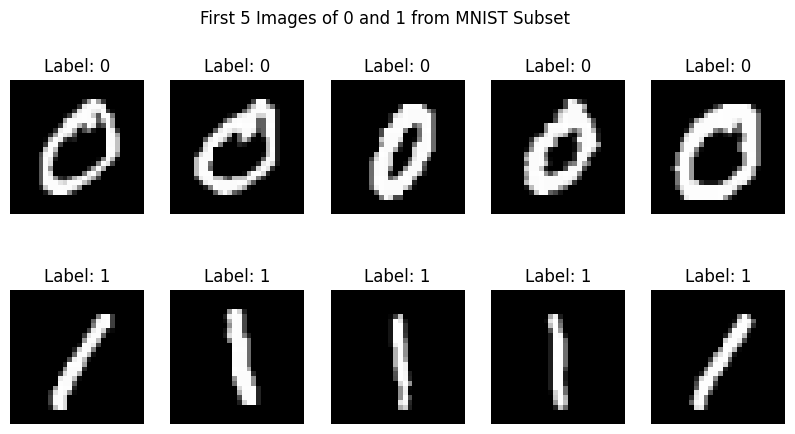

In [13]:
images_0 = X[y == 0] # Select all images where label is 0
images_1 = X[y == 1] # Select all images where label is 1

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

if len(images_0) < 5 or len(images_1) < 5:
    print("Not enough images to plot.")
else:
    for i in range(5):
      # Displays the i-th digit 0 image in the first row by reshaping its 784 pixels into a 28×28 grayscale image
        axes[0, i].imshow(images_0[i].reshape(28, 28), cmap="gray")
        axes[0, i].set_title("Label: 0")
        axes[0, i].axis("off")
      # Displays the i-th digit 1 image in the second row by reshaping its 784 pixels into a 28×28 grayscale image
        axes[1, i].imshow(images_1[i].reshape(28, 28), cmap="gray")
        axes[1, i].set_title("Label: 1")
        axes[1, i].axis("off")

plt.suptitle("First 5 Images of 0 and 1 from MNIST Subset")

### Initialize Weights and Bias:

In [14]:
# Initialize weights and bias
weights = np.zeros(X.shape[1]) # 784 weights (one for each pixel)
bias = 0
learning_rate = 0.1
epochs = 100  # Number of times to loop over dataset

3. Question - 3: What does the weights array represent in this context?


Each of the 784 weights corresponds to a pixel in the input image. A higher weight means the pixel has more influence on the perceptron’s decision, while a weight near 0 means the pixel has little impact.


4. Question - 4: Why are we initializing the weights to zero? What effect could this have on the training process?

Weights are initialized to zero so all pixels are treated equally at the start, giving a neutral starting point.

For a simple perceptron, this works fine. However in deeper networks, zero initialization can cause the symmetry problem, where all neurons learn the same features, which is why random initialization is preferred in practice.

### Implement a Decision Function or Activation Function:

In [15]:
#Prediction Phase
def decision_function(X, weights, bias):
    """
    Computes predicted labels using the step activation function.
    z = dot(X, weights) + bias
    output = 1 if z >= 0, else 0
    """
    #It multiplies every pixel by its weight and adds the bias.
    z = np.dot(X, weights) + bias          # weighted sum for all samples at once
    y_pred_all = np.where(z >= 0, 1, 0)   # step function converts scores to 1 or 0
    return y_pred_all

### Implement the Perceptron Learning Algorithm:

In [16]:
#Training phase
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):
    """
    Trains the perceptron using the perceptron learning rule.
    Updates weights only when a sample is misclassified.
    Returns: updated weights, bias, and final accuracy.
    """
    #Outer loop that repeats the training process multiple times
    for epoch in range(epochs):
        convergence_flag = True  #assume the model is perfect at the start of every epoch

        #Inner loop that looks at every single image one by one
        for i in range(len(X)):
            # Step A: compute weighted sum for one image
            z = np.dot(X[i], weights) + bias

            # Step B: apply step function to get prediction
            y_hat = 1 if z >= 0 else 0

            # Step C: update weights only if prediction is wrong
            if y_hat != y[i]:
                error = y[i] - y_hat       # Calculates the mistake. If the true label is 1 but we predicted 0, error is +1.
                weights = weights + learning_rate * error * X[i]
                bias    = bias    + learning_rate * error
                convergence_flag = False   # at least one update happened

        # Stop early if no updates happened in this epoch
        if convergence_flag:
            print(f"Converged at epoch {epoch + 1}")
            break

    # Calculate final accuracy over the whole dataset
    y_pred = decision_function(X, weights, bias)
    accuracy = np.mean(y_pred == y)
    return weights, bias, accuracy

5. Question - 5: What is the purpose of the output = np.dot(X[i], weights) + bias line?

It computes the weighted sum of inputs plus bias for one image. This is the raw score the perceptron gives before the step function decides the class.

6. Question - 6: What happens when the prediction is wrong? How are the weights and
bias updated?

When the prediction is incorrect, the weights and bias are updated using the error.

If error = +1 (predicted 0, true 1); weights increase toward x, making the neuron more likely to fire for similar inputs next time.

If error = −1 (predicted 1, true 0): weights decrease.

7. Question - 7:Why is the final accuracy important, and what do you expect it to be?

Accuracy tells us what percentage of images were correctly classified. For 0 vs 1 we expect near 100% because 0 and 1 look very different.

### Putting it all Together:

In [24]:
weights, bias, accuracy = train_perceptron(X, y, weights, bias,
                                           learning_rate, epochs)
print(f"Final Training Accuracy: {accuracy:.4f}")

Converged at epoch 1
Final Training Accuracy: 1.0000


### Visualizing the Misclassified Image:

Final Accuracy: 1.0000
Correct:        12665
Misclassified:  0


Text(0.5, 0.98, 'Sample Correctly Classified Images (row 1 = class 0, row 2 = class 1)')

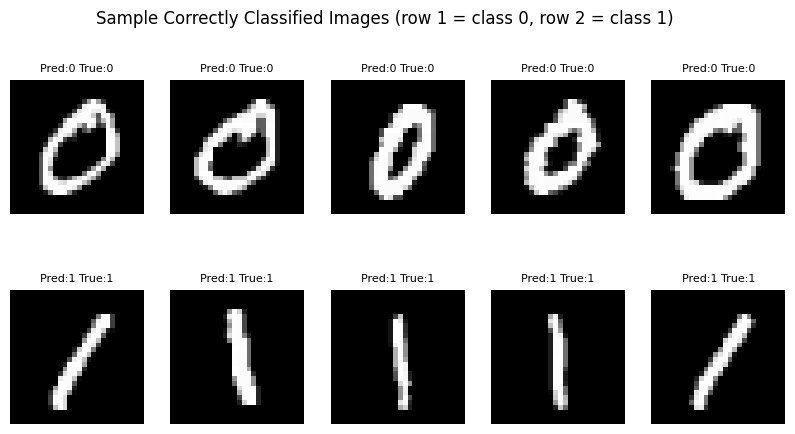

In [18]:
y_pred = decision_function(X, weights, bias) #Calculatin gperformance
final_accuracy = np.mean(y_pred == y)
print(f"Final Accuracy: {final_accuracy:.4f}")

misclassified_idx = np.where(y_pred != y)[0] #This stores the indices of all images the model got wrong.
correct_idx       = np.where(y_pred == y)[0] #This stores the indices of all images the model got right.
print(f"Correct:        {len(correct_idx)}")
print(f"Misclassified:  {len(misclassified_idx)}")

# Shows 10 images the model got right, split by class.
correct_0 = correct_idx[y[correct_idx] == 0][:5]
correct_1 = correct_idx[y[correct_idx] == 1][:5]

fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for i, idx in enumerate(correct_0):
    axes[0, i].imshow(X[idx].reshape(28, 28), cmap="gray")
    axes[0, i].set_title(f"Pred:{y_pred[idx]} True:{y[idx]}", fontsize=8)
    axes[0, i].axis("off")
for i, idx in enumerate(correct_1):
    axes[1, i].imshow(X[idx].reshape(28, 28), cmap="gray")
    axes[1, i].set_title(f"Pred:{y_pred[idx]} True:{y[idx]}", fontsize=8)
    axes[1, i].axis("off")
plt.suptitle("Sample Correctly Classified Images (row 1 = class 0, row 2 = class 1)")

8. Question - 8:What does misclassified idx store, and how is it used in this code?

It stores the indices of incorrectly classified images.(y_pred ≠ y) It is used to count and visualize errors.

9. Question - 9: How do you interpret the result if the output is ”All images were
correctly classified!”?

It means the perceptron found a perfect linear decision boundary that separates all 0s from all 1s in the training data. This is expected for 0 vs 1 because the two digits look very different and are linearly separable in pixel space.

## 4.4 Task 3: Perceptron Algorithm for 3 vs 5 Classification.

## 4.5 To - Do:

Feature matrix shape: (2741, 784)
Label vector shape:   (2741,)
Unique labels:        [3 5]


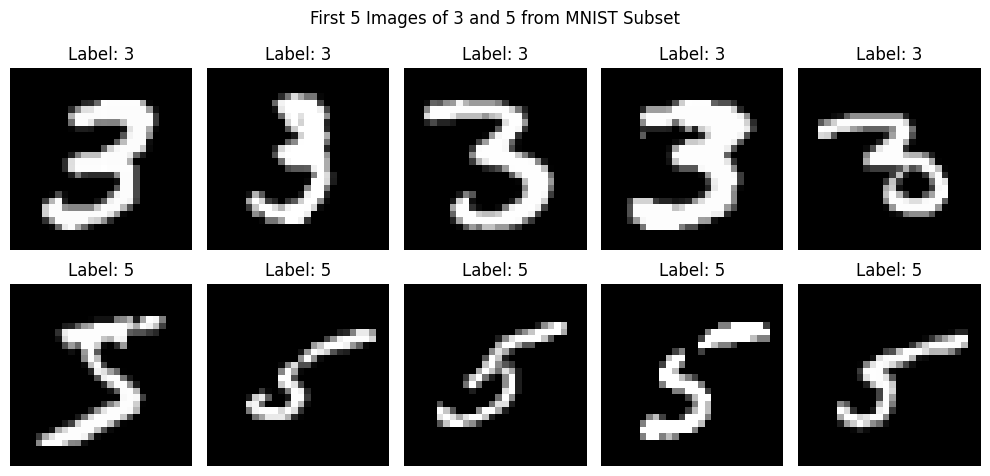

In [19]:
# Load 3 vs 5 dataset
df_3_5 = pd.read_csv("mnist_3_and_5.csv")

X_35 = df_3_5.drop(columns=["label"]).values # Remove label column → only pixel values (features)
y_35 = df_3_5["label"].values # Extract label column → target values (3 or 5)

print("Feature matrix shape:", X_35.shape)
print("Label vector shape:  ", y_35.shape)
print("Unique labels:       ", np.unique(y_35))

# Visualize
images_3 = X_35[y_35 == 3] #Selects all the image where label is 3
images_5 = X_35[y_35 == 5] #Selects all the image where label is 5


fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for i in range(5):
    axes[0, i].imshow(images_3[i].reshape(28, 28), cmap="gray")
    axes[0, i].set_title("Label: 3")
    axes[0, i].axis("off")

    axes[1, i].imshow(images_5[i].reshape(28, 28), cmap="gray")
    axes[1, i].set_title("Label: 5")
    axes[1, i].axis("off")

plt.suptitle("First 5 Images of 3 and 5 from MNIST Subset")
plt.tight_layout()

In [20]:
# Remap labels so the perceptron can use them
# 3 becomes 0, 5 becomes 1
y_35_binary = np.where(y_35 == 3, 0, 1)

print("Original labels sample: ", y_35[:8])
print("Remapped labels sample: ", y_35_binary[:8])

Original labels sample:  [5 3 3 5 3 3 3 5]
Remapped labels sample:  [1 0 0 1 0 0 0 1]


In [21]:
# Weights and bias
weights_35    = np.zeros(X_35.shape[1])
bias_35       = 0
learning_rate = 0.1
epochs        = 100

# Train using the same function from Task 2
weights_35, bias_35, accuracy_35 = train_perceptron(
    X_35, y_35_binary, weights_35, bias_35, learning_rate, epochs
)

Final Training Accuracy (3 vs 5): 0.9869
Correct:        2705
Misclassified:  36


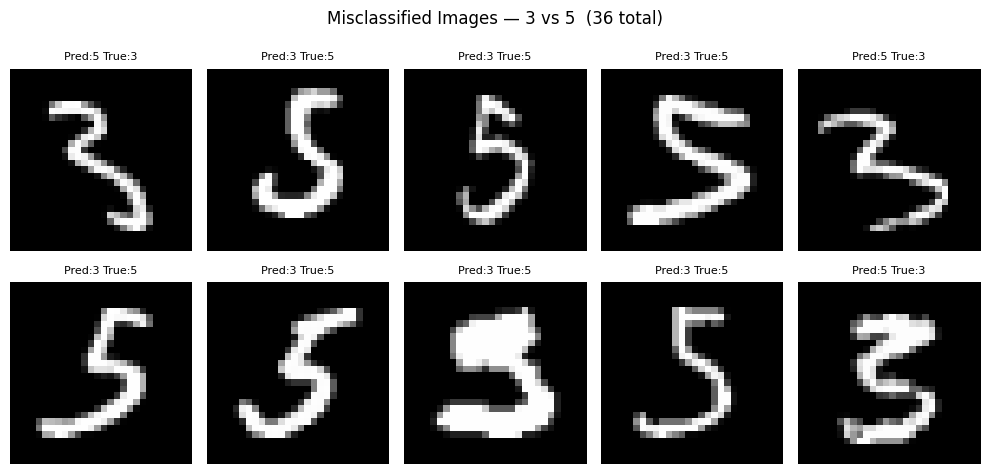

In [25]:
#Get predictions for the summary
y_pred_35 = decision_function(X_35, weights_35, bias_35)

# Calculate counts
misclassified_35 = np.where(y_pred_35 != y_35_binary)[0]
correct_35 = np.where(y_pred_35 == y_35_binary)[0]

print(f"Final Training Accuracy (3 vs 5): {accuracy_35:.4f}")
print(f"Correct:        {len(correct_35)}")
print(f"Misclassified:  {len(misclassified_35)}")

if len(misclassified_35) == 0:
    print("All images were correctly classified!")
else:
    n_show = min(10, len(misclassified_35))
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for ax, idx in zip(axes.flat, misclassified_35[:n_show]):
        true_label = y_35[idx]           # original label (3 or 5)
        pred_label = 3 if y_pred_35[idx] == 0 else 5   # convert back for display
        ax.imshow(X_35[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred:{pred_label} True:{true_label}", fontsize=8)
        ax.axis("off")
    plt.suptitle(f"Misclassified Images — 3 vs 5  ({len(misclassified_35)} total)")
    plt.tight_layout()